# Image Segmenation: YOLO v8 Segmentation Model

### Create directories

In [ ]:
# Set up folders like this:

# labels/train
# masks/train

import os
import shutil
import glob

# Make folders
os.makedirs("labels/train", exist_ok=True)
os.makedirs("masks/train", exist_ok=True)

### Create Masks

In [ ]:
import os
import shutil

# Delete existing labels directory
if os.path.exists("dataset/labels"):
    shutil.rmtree("dataset/labels")

# Re-create directories
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

# NOW re-run your rgb_mask_to_yolo_polygons function to generate clean labels!

In [ ]:
import cv2
import numpy as np

# Segmented Image
SEG_IMAGE_1 = "segmented_tournament_R2026011_player_46046_hole_16_round_4.png"
SEG_IMAGE_2 = "segmented_tournament_R2026011_player_46046_hole_17_round_4.png"

# Define color maps (R, G, B) to Class IDs
COLOR_MAP = {
    (231, 25, 31):  0,      # Red (Fairway)
    (250, 255, 0):  1,      # Yellow (Rough)
    (255, 166, 41): 2,     # Orange (Sand)
    (13, 153, 255): 3,     # Blue (Water)
    (151, 71, 255): 4,     # Purple (Trees)
    (20, 174, 92):  5,      # Green (Putting Green)
    (0, 232, 255):  6,      # Cyan (Cart path)
    (255, 0, 214):  7,      # Pink (UI, User Interface)
}

def rgb_mask_to_yolo_polygons(mask_path, color_map, tolerance=20):
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    h, w, _ = mask.shape
    yolo_lines = []

    for rgb, class_id in color_map.items():
        # Find pixels matching the color within a tolerance
        lower = np.array([max(0, c - tolerance) for c in rgb])
        upper = np.array([min(255, c + tolerance) for c in rgb])
        binary_mask = cv2.inRange(mask, lower, upper)

        # Find contours of the segment
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cv2.contourArea(cnt) < 50:  # Ignore tiny noise
                continue
            # Normalize contour coordinates between 0.0 and 1.0
            polygon = cnt.reshape(-1, 2) / [w, h]
            poly_str = " ".join([f"{x:.6f} {y:.6f}" for x, y in polygon])
            yolo_lines.append(f"{class_id} {poly_str}")

    return yolo_lines

polygons_1 = rgb_mask_to_yolo_polygons(SEG_IMAGE_1, COLOR_MAP)
polygons_2 = rgb_mask_to_yolo_polygons(SEG_IMAGE_2, COLOR_MAP)

# Save to YOLO txt format
with open("dataset/labels/train/tournament_R2026011_player_46046_hole_16_round_4.txt", "w") as f:
    f.write("\n".join(polygons_1))

with open("dataset/labels/val/tournament_R2026011_player_46046_hole_17_round_4.txt", "w") as f:
    f.write("\n".join(polygons_2))

In [ ]:
def rgb_mask_to_class_mask(mask_path, color_map):
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    class_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)

    for rgb, class_id in color_map.items():
        # Identify matching pixel locations
        matches = np.all(np.abs(mask - rgb) < 20, axis=-1)
        class_mask[matches] = class_id

    return class_mask  # Single channel (H, W) image

# Save grayscale class mask
class_mask = rgb_mask_to_class_mask(SEG_IMAGE_1, COLOR_MAP)
cv2.imwrite("masks/train/image_001.png", class_mask)

NameError: name 'SEG_IMAGE' is not defined

### Organize Files

In [ ]:
# dataset/
# ├── dataset.yaml
# ├── images/
# │   ├── train/ (e.g., tournament_R2026011_hole_16.jpg)
# │   └── val/
# └── labels/
#     ├── train/ (e.g., tournament_R2026011_hole_16.txt)
#     └── val/

# Make folders
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

In [ ]:
# make yaml file

yaml_lines = """
path: ./dataset
train: images/train
val: images/val

names:
  0: fairway
  1: rough
  2: sand
  3: water
  4: trees
  5: green
  6: cart_path
  7: UI
"""
with open("dataset/dataset.yaml", "w") as file:
    file.write(yaml_lines)

### Run YOLOv8 Segmentation

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Remove cache files if they exist
for cache in ["dataset/labels/train.cache", "dataset/labels/val.cache"]:
    if os.path.exists(cache):
        os.remove(cache)

model = YOLO("yolov8n-seg.pt")

# Train on your dataset
model.train(
    data="dataset/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device="cpu"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7df19fa73170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0

### Results


image 1/1 /content/dataset/images/val/tournament_R2026011_player_46046_hole_17_round_4.png: 416x640 (no detections), 427.7ms
Speed: 3.5ms preprocess, 427.7ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)


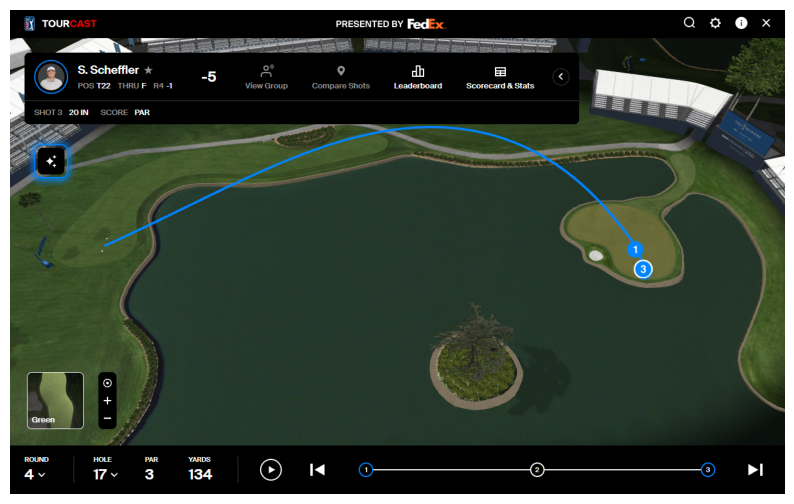

In [ ]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/yolov8n-seg.pt")

# Run inference
results = model("/content/dataset/images/val/tournament_R2026011_player_46046_hole_17_round_4.png")

# Render annotated BGR image array
annotated_frame = results[0].plot()

# Convert BGR to RGB for matplotlib display
rgb_frame = annotated_frame[..., ::-1]

# Display image inline
plt.figure(figsize=(10, 10))
plt.imshow(rgb_frame)
plt.axis("off")
plt.show()

In [ ]:
# Predict and auto-save annotated images to 'runs/segment/predict/'
model.predict(source="dataset/images/val", save=True, conf=0.25)


image 1/1 /content/dataset/images/val/tournament_R2026011_player_46046_hole_17_round_4.png: 416x640 (no detections), 228.8ms
Speed: 3.1ms preprocess, 228.8ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/segment/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 


image 1/1 /content/dataset/images/val/tournament_R2026011_player_46046_hole_17_round_4.png: 416x640 (no detections), 182.9ms
Speed: 2.5ms preprocess, 182.9ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)


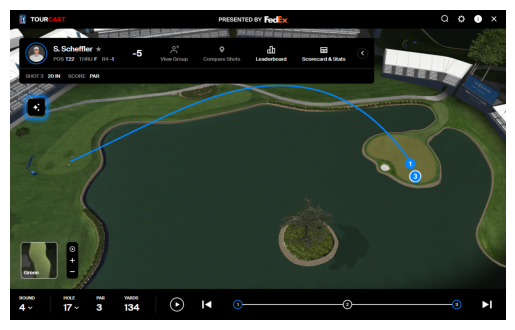

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

model = YOLO("/content/yolov8n-seg.pt")
results = model("/content/dataset/images/val/tournament_R2026011_player_46046_hole_17_round_4.png")

res = results[0]
orig_img = res.orig_img.copy()  # Original image (BGR)

# Check if any masks were detected
if res.masks is not None:
    # Get all binary masks as boolean numpy arrays (N, H, W)
    masks = res.masks.data.cpu().numpy()
    classes = res.boxes.cls.cpu().numpy().astype(int)

    for i, mask in enumerate(masks):
        class_id = classes[i]
        class_name = res.names[class_id]

        # Resize mask to original image size if needed
        mask_resized = cv2.resize(
            mask.astype(np.uint8),
            (orig_img.shape[1], orig_img.shape[0]),
            interpolation=cv2.INTER_NEAREST,
        )

        print(f"Detected class {class_id} ({class_name}) with area: {np.sum(mask_resized)} pixels")

# Convert original BGR to RGB for plotting
plt.imshow(orig_img[..., ::-1])
plt.axis("off")
plt.show()